### Fine-tuning a YOLOv8 Model Using a Custom Dataset

This notebook demonstrates how to fine-tune a YOLOv8 model using a previously generated custom dataset.

---

### Folder Structure

- `this_notebook.ipynb`
- `Dataset_yolo/`
  - `Images/`
    - `Train_images/`
    - `Val_images/`
  - `Labels/`
    - `Train_labels/`
    - `Val_labels/`
  - `Depth/` (this is not used for training)
    - `Train_labels/`
    - `Val_labels/`






In [1]:
# ONLY RUN GOOGLE COLAB, Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
cd /content/drive/MyDrive/'Colab Notebooks/human-activity-understanding/HW2'

/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2


Visualizing 3 random images and their depth maps...


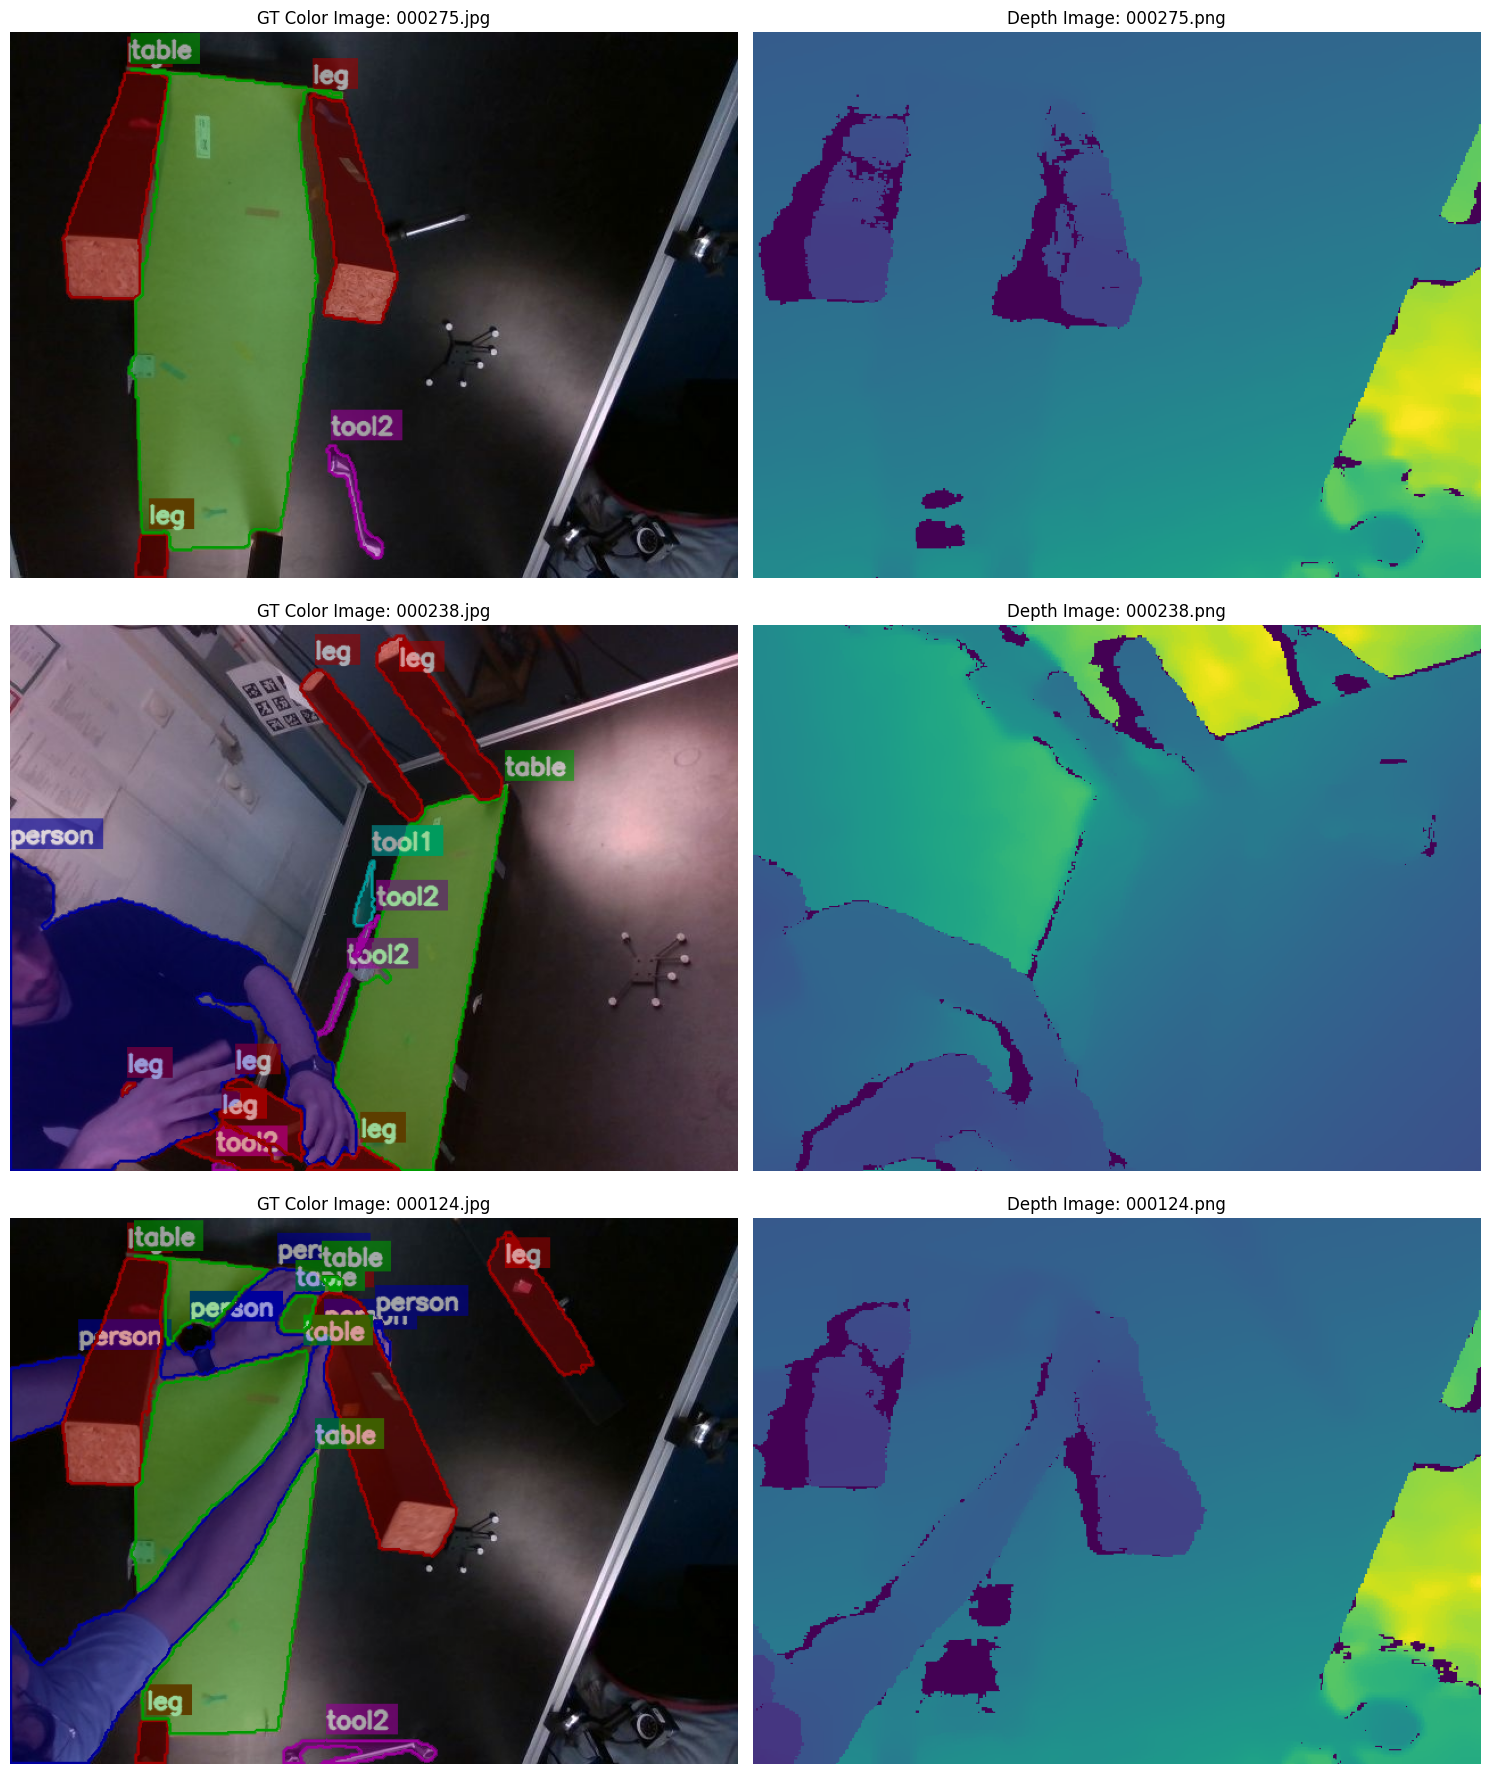

Finished visualizing 3 images with color annotations and depth maps.


In [3]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np # numpy is used in draw_bboxes_and_labels

# Re-define CLASSES as it was not in the current scope
CLASSES = ['person','table', 'leg','tool1', 'tool2']

def parse_yolo_label(label_path, img_width, img_height):
    """
    Parses a YOLO format segmentation label file and returns a list of masks.
    Each mask is returned as (class_id, polygon_points) where polygon_points is a list of (x, y) tuples in pixel coordinates.
    """
    masks = []
    if not os.path.exists(label_path):
        print(f"Warning: Label file not found: {label_path}")
        return masks

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3: # Must have at least class_id, x1, y1
                class_id = int(parts[0])
                polygon_normalized = list(map(float, parts[1:]))

                # Convert normalized coordinates to pixel coordinates
                polygon_points = []
                for i in range(0, len(polygon_normalized), 2):
                    x = int(polygon_normalized[i] * img_width)
                    y = int(polygon_normalized[i+1] * img_height)
                    polygon_points.append((x, y))
                masks.append((class_id, polygon_points))
    return masks

def draw_bboxes_and_labels(image, masks, classes):
    """
    Draws segmentation masks and class labels on an image with semi-transparent colors.
    """
    img_copy = image.copy()
    overlay = img_copy.copy()
    alpha = 0.4  # Transparency factor

    # Define a set of distinct colors for classes (BGR format for OpenCV)
    class_colors = [
        (0, 0, 155),    # Red for class 0 (person)
        (0, 155, 0),    # Green for class 1 (table)
        (155, 0, 0),    # Blue for class 2 (leg)
        (0, 155, 155),  # Yellow for class 3 (tool1)
        (155, 0, 155)   # Magenta for class 4 (tool2)
    ]

    for class_id, polygon_points in masks:
        if polygon_points:
            # Get color for the class
            color = class_colors[class_id % len(class_colors)] if class_id < len(class_colors) else (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) # Fallback random color

            # Reshape points for cv2.fillPoly and cv2.polylines
            pts = np.array(polygon_points, np.int32)
            pts = pts.reshape((-1, 1, 2))

            # Fill the polygon on the overlay with semi-transparency
            cv2.fillPoly(overlay, [pts], color)

            # Draw polygon outline
            cv2.polylines(img_copy, [pts], True, color, 2)

            # Put label
            label = classes[class_id] if class_id < len(classes) else f"Unknown Class {class_id}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.7
            font_thickness = 2
            text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]

            # Place text near the first point of the polygon
            text_x = polygon_points[0][0]
            text_y = polygon_points[0][1] - 10 if polygon_points[0][1] - 10 > text_size[1] else polygon_points[0][1] + text_size[1] + 10

            # Draw background for text
            cv2.rectangle(img_copy, (text_x, text_y - text_size[1] - 5),
                          (text_x + text_size[0] + 5, text_y + 5), color, -1)
            cv2.putText(img_copy, label, (text_x, text_y), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)

    # Combine the original image with the overlay using the transparency factor
    img_with_masks = cv2.addWeighted(overlay, alpha, img_copy, 1 - alpha, 0)
    return img_with_masks

# Define the new directories
TRAIN_IMAGES_DIR = 'dataset_yolo/images/val'
TRAIN_LABELS_DIR = 'dataset_yolo/labels/val'
TRAIN_DEPTH_DIR = 'dataset_yolo/depth/val' # New: Define depth directory

# Get a list of all image files in the new training directory
train_image_files = [f for f in os.listdir(TRAIN_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg'))]

# Randomly select 3 images to visualize
num_images_to_visualize = min(3, len(train_image_files)) # Ensure we don't try to visualize more than available
selected_images_for_viz = random.sample(train_image_files, num_images_to_visualize)

print(f"Visualizing {num_images_to_visualize} random images and their depth maps...")

plt.figure(figsize=(15, 6 * num_images_to_visualize))

for i, img_filename in enumerate(selected_images_for_viz):
    img_path = os.path.join(TRAIN_IMAGES_DIR, img_filename)
    label_filename = os.path.splitext(img_filename)[0] + '.txt'
    label_path = os.path.join(TRAIN_LABELS_DIR, label_filename)
    depth_filename = os.path.splitext(img_filename)[0] + '.png'
    depth_path = os.path.join(TRAIN_DEPTH_DIR, depth_filename)

    # Read the color image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image: {img_path}")
        continue

    # OpenCV reads images as BGR, convert to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read the depth image
    depth_image = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    if depth_image is None:
        print(f"Warning: Could not read depth image: {depth_path}")
        continue

    img_height, img_width, _ = img_rgb.shape

    # Parse YOLO labels
    bboxes = parse_yolo_label(label_path, img_width, img_height)

    # Draw bounding boxes and labels on the color image
    img_with_boxes = draw_bboxes_and_labels(img_rgb, bboxes, CLASSES)

    # Normalize depth image for visualization
    # Scale to 0-255 for 8-bit display
    normalized_depth_image = cv2.normalize(depth_image, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # Display the annotated color image
    plt.subplot(num_images_to_visualize, 2, i * 2 + 1) # First column for color image
    plt.imshow(img_with_boxes)
    plt.title(f"GT Color Image: {img_filename}")
    plt.axis('off')

    # Display the normalized depth image
    plt.subplot(num_images_to_visualize, 2, i * 2 + 2) # Second column for depth image
    plt.imshow(normalized_depth_image, cmap='viridis')
    plt.title(f"Depth Image: {depth_filename}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Finished visualizing {num_images_to_visualize} images with color annotations and depth maps.")

### Install Ultralytics

In [4]:
get_ipython().system('pip install ultralytics')
print("ultralytics package installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.0 MB/s eta 0:00:00
ultralytics package installed.


## Load Pre-trained Ultralytics Model

Load a suitable pre-trained YOLOv8 from the `ultralytics` hub as a starting point for fine-tuning.


In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 segmentation model
model = YOLO('yolov8n-seg.pt')

print("Pre-trained YOLOv8 segmentation model 'yolov8n-seg.pt' loaded successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Pre-trained YOLOv8 segmentation model 'yolov8n-seg.pt' loaded successfully.


# Task 1.1
## Fine-tuning yolov8 using custom dataset

Define the training parameters (data.yaml), including the number of epochs, batch size, and most importantly, adjust the model to match the number of classes in your custom dataset.


In [ ]:
model.train(data='data.yaml', epochs=100, imgsz=640, name='yolov8n_seg_custom')
print("Model training initiated with custom dataset and specified parameters.")

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_seg_custom2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

# Task 1.2
## Test Fine-tuned Model


Test the fine-tuned YOLOv8 segmentation model on validation images and visualize the results, including bounding boxes and semi-transparent segmentation masks.


In [5]:
import cv2
import numpy as np
import random

def draw_rect_boxes_and_labels(image, boxes, classes):
    """
    Draws rectangular bounding boxes and class labels on an image.
    """
    img_copy = image.copy()

    # Define a set of distinct colors for classes (BGR format for OpenCV)
    class_colors = [
        (0, 0, 155),    # Red for class 0 (person)
        (0, 155, 0),    # Green for class 1 (table)
        (155, 0, 0),    # Blue for class 2 (leg)
        (0, 155, 155),  # Yellow for class 3 (tool1)
        (155, 0, 155)   # Magenta for class 4 (tool2)
    ]

    if boxes is not None and len(boxes) > 0:
        for box_data in boxes:
            x1, y1, x2, y2 = map(int, box_data.xyxy[0])
            class_id = int(box_data.cls[0])
            confidence = float(box_data.conf[0]) # Extract confidence score

            # Get color for the class
            color = class_colors[class_id % len(class_colors)] if class_id < len(class_colors) else (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) # Fallback random color

            # Draw rectangle
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)

            # Put label
            label = classes[class_id] if class_id < len(classes) else f"Unknown Class {class_id}"
            label_with_score = f"{label} ({confidence:.2f})" # Append confidence score
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.7
            font_thickness = 2
            text_size = cv2.getTextSize(label_with_score, font, font_scale, font_thickness)[0]

            # Place text above the bounding box
            text_x = x1
            text_y = y1 - 10 if y1 - 10 > text_size[1] else y1 + text_size[1] + 10

            # Draw background for text
            cv2.rectangle(img_copy, (text_x, text_y - text_size[1] - 5),
                          (text_x + text_size[0] + 5, text_y + 5), color, -1)
            cv2.putText(img_copy, label_with_score, (text_x, text_y), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)

    return img_copy

print("New helper function `draw_rect_boxes_and_labels` defined to draw only rectangular bounding boxes and labels.")

New helper function `draw_rect_boxes_and_labels` defined to draw only rectangular bounding boxes and labels.


In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the best trained model weights
model_path = os.path.join('runs', 'segment', 'yolov8n_seg_custom', 'weights', 'best.pt')
model = YOLO(model_path)

print(f"Loaded fine-tuned model from: {model_path}")

# Define the new directories and classes (same as used for training)

CLASSES = ['person', 'table', 'leg', 'tool1', 'tool2']

# Path to the YOLO dataset validation images
val_images_dir = os.path.join('dataset_yolo', 'images', 'val')
val_labels_dir = os.path.join('dataset_yolo', 'labels', 'val')
val_depth_dir = os.path.join('dataset_yolo', 'depth', 'val')

# Get a list of all image files in the validation directory
val_image_files = [f for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded fine-tuned model from: runs/segment/yolov8n_seg_custom/weights/best.pt


Visualizing 1 random validation images with color, depth, and ROIs...



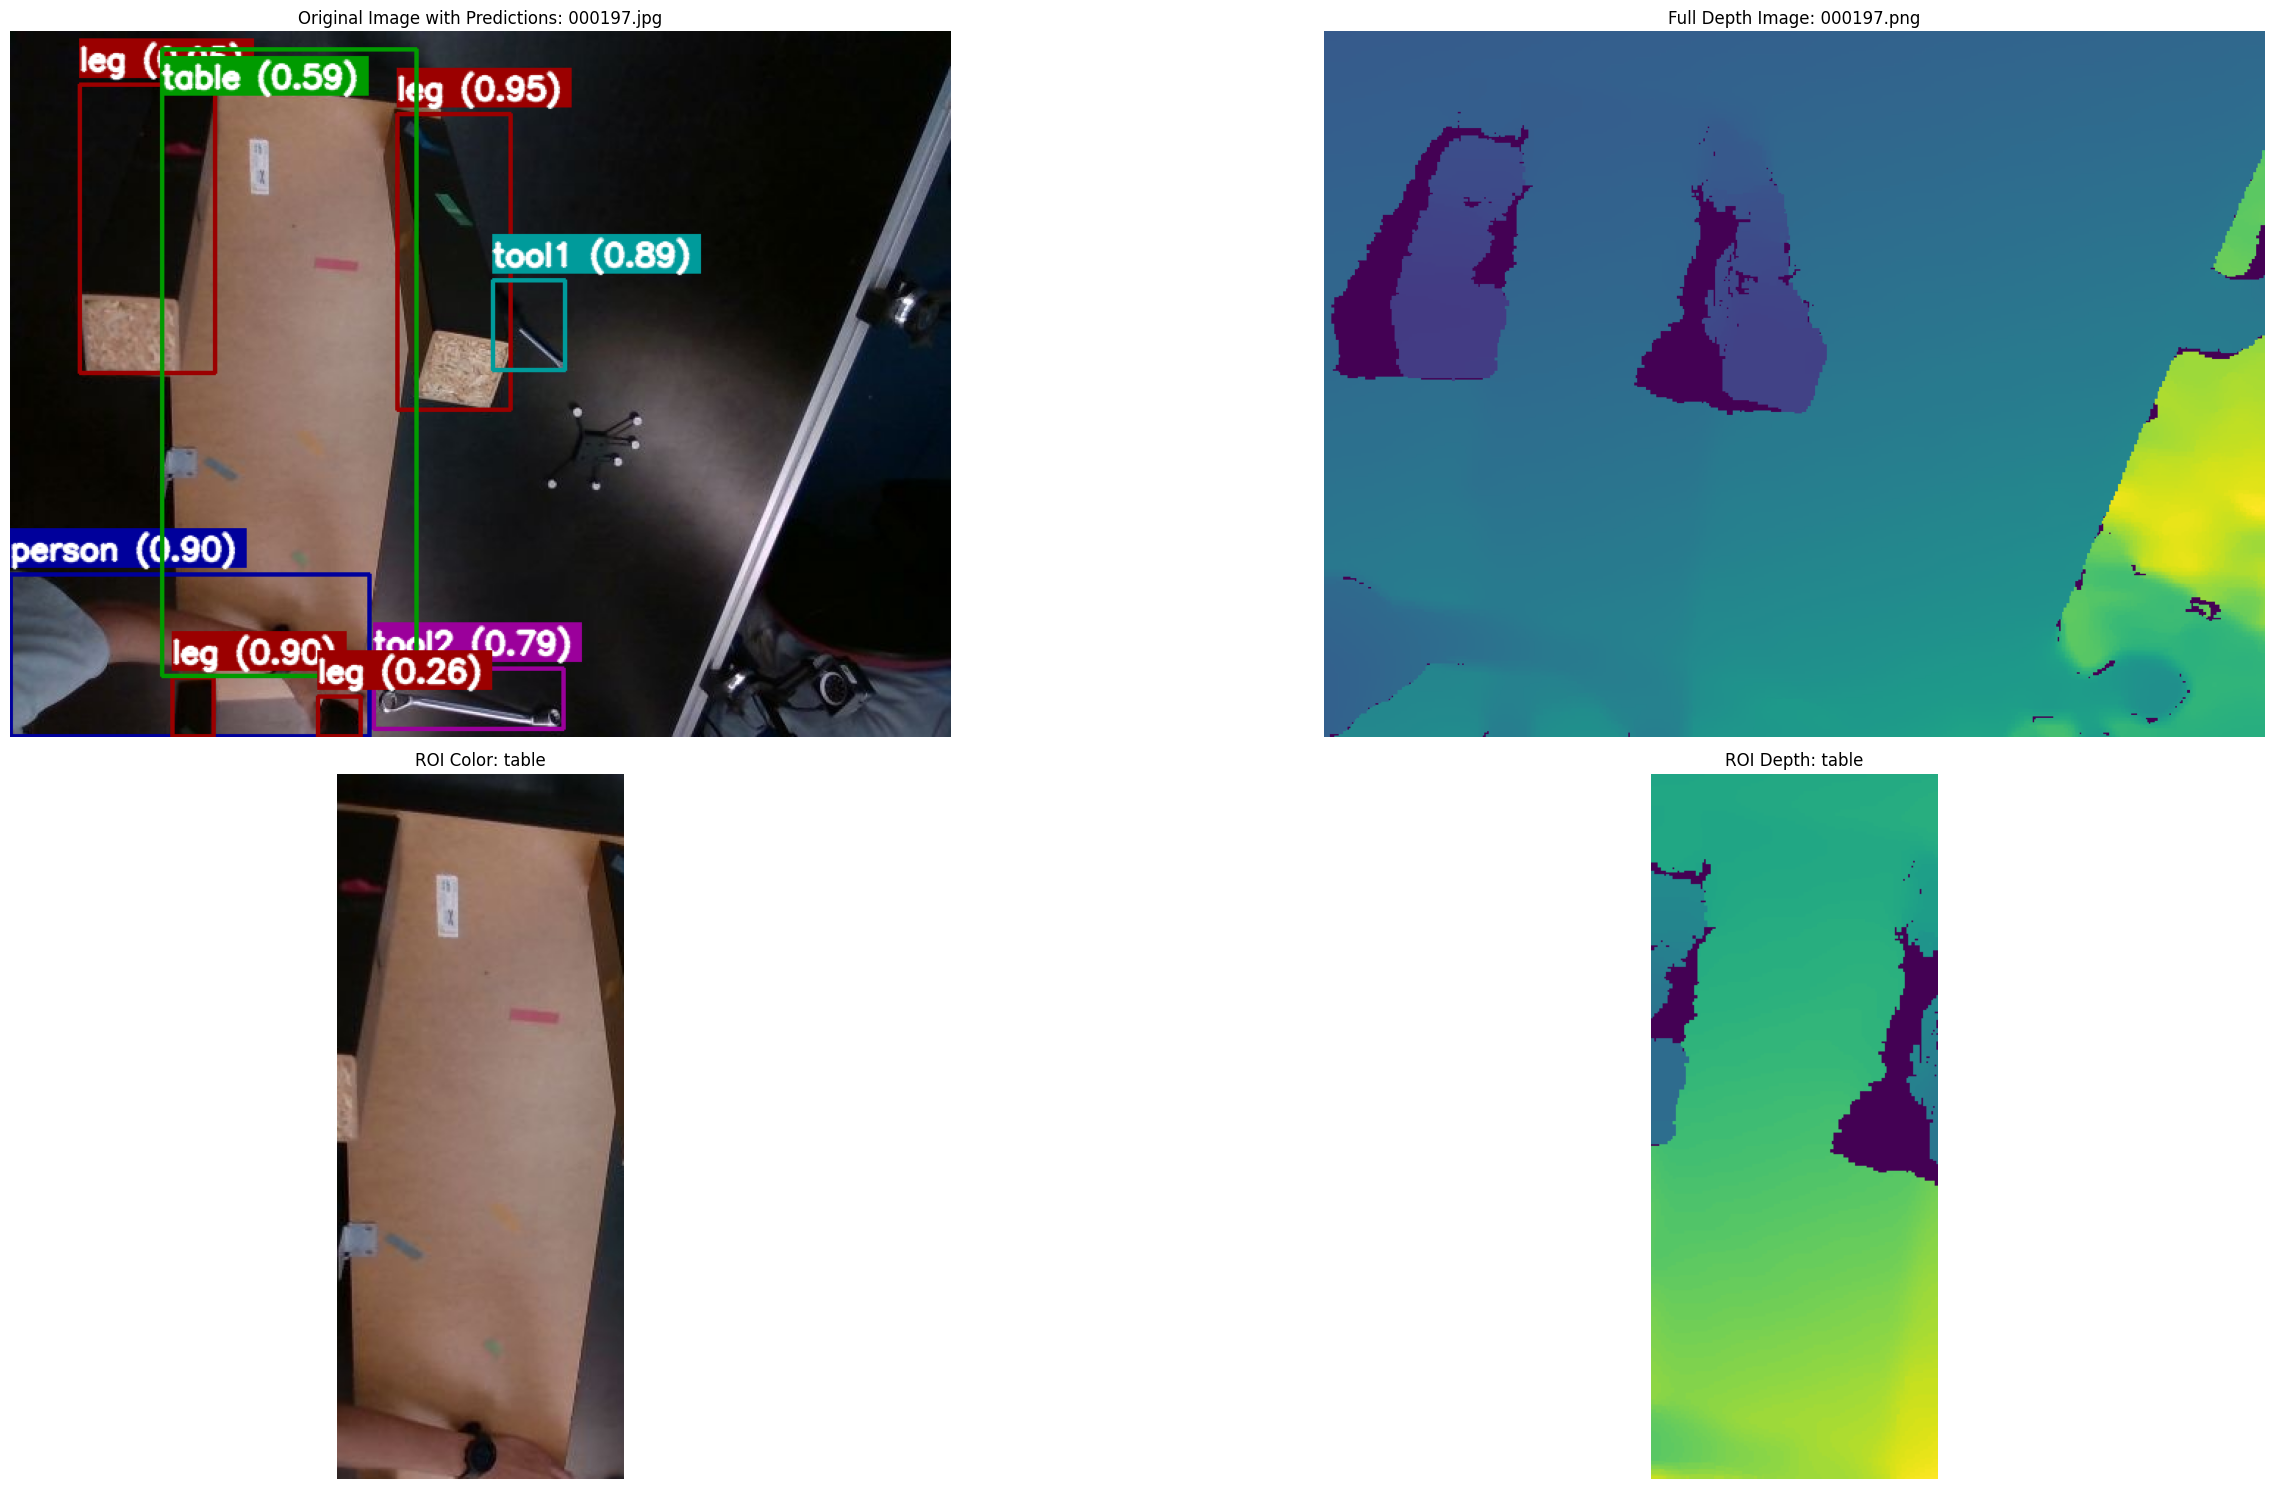

Finished visualizing 1 validation images with color, depth, and ROIs.


In [7]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np # Ensure numpy is imported if not already in scope via another cell

# Define CLASSES (ensure it's in scope)
CLASSES = ['person', 'table', 'leg', 'tool1', 'tool2']

# Path to the YOLO dataset validation images
val_images_dir = os.path.join('dataset_yolo', 'images', 'val')
val_labels_dir = os.path.join('dataset_yolo', 'labels', 'val')
val_depth_dir = os.path.join('dataset_yolo', 'depth', 'val') # Added definition here

# Randomly select one images to visualize from the validation set
num_images_to_visualize = min(1, len(val_image_files)) # Ensure we don't try to visualize more than available
selected_images_for_viz = random.sample(val_image_files, num_images_to_visualize)

print(f"Visualizing {num_images_to_visualize} random validation images with color, depth, and ROIs...\n")

# Adjust figsize to accommodate 2 rows of 2 images each (assuming num_images_to_visualize=1)
plt.figure(figsize=(30, 15))

for i, img_filename in enumerate(selected_images_for_viz):
    img_path = os.path.join(val_images_dir, img_filename)
    depth_filename = os.path.splitext(img_filename)[0] + '.png'
    depth_path = os.path.join(val_depth_dir, depth_filename)

    # Read the color image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image: {img_path}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read the depth image
    depth_image = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    if depth_image is None:
        print(f"Warning: Could not read depth image: {depth_path}")
        continue
    normalized_depth_image = cv2.normalize(depth_image, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)


    # Run inference
    results = model(img_rgb, verbose=False)

    # --- Logic to find the object for ROI display ---
    selected_bbox_for_roi = None
    selected_class_id_for_roi = None
    all_detected_boxes = [] # Collect all boxes for the first subplot
    found_table_for_roi = False

    for r in results:
        if r.boxes and len(r.boxes) > 0:
            # Collect all boxes for displaying all detections
            all_detected_boxes.extend(r.boxes)

            # Prioritize finding a 'table' object (class ID 1)
            if not found_table_for_roi: # Only search if table hasn't been found yet
                for j in range(len(r.boxes)):
                    current_class_id = int(r.boxes.cls[j])
                    if current_class_id == 1: # Class ID for 'table'
                        selected_bbox_for_roi = r.boxes[j]
                        selected_class_id_for_roi = current_class_id
                        found_table_for_roi = True
                        break # Found table, exit inner loop
        if found_table_for_roi: # Found table, exit outer loop
            break

    # If no 'table' was found, fall back to the first detected object (if any)
    if not found_table_for_roi and all_detected_boxes:
        selected_bbox_for_roi = all_detected_boxes[0]
        selected_class_id_for_roi = int(all_detected_boxes[0].cls[0])
    # --- End of ROI object selection logic ---


    # --- First Row: All Detections and Full Depth Image ---
    # Display the annotated color image (all detections)
    img_with_all_predictions = img_rgb.copy()
    img_with_all_predictions = draw_rect_boxes_and_labels(img_rgb.copy(), all_detected_boxes, CLASSES)
    plt.subplot(2, 2, 1) # First row, first column
    plt.imshow(img_with_all_predictions)
    plt.title(f"Original Image with Predictions: {img_filename}")
    plt.axis('off')

    # Display the normalized depth image
    plt.subplot(2, 2, 2) # First row, second column
    plt.imshow(normalized_depth_image, cmap='viridis')
    plt.title(f"Full Depth Image: {depth_filename}")
    plt.axis('off')


    # --- Second Row: ROI for Selected Object (Color and Depth) ---
    if selected_bbox_for_roi is not None:
        x1, y1, x2, y2 = map(int, selected_bbox_for_roi.xyxy[0].cpu().numpy())

        # Ensure coordinates are within image bounds
        img_height, img_width, _ = img_rgb.shape
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_width, x2)
        y2 = min(img_height, y2)

        # Crop color ROI
        cropped_color_roi = img_rgb[y1:y2, x1:x2]
        # Crop depth ROI
        cropped_depth_roi = normalized_depth_image[y1:y2, x1:x2]

        # Display cropped color ROI
        plt.subplot(2, 2, 3) # Second row, first column
        plt.imshow(cropped_color_roi)
        plt.title(f"ROI Color: {CLASSES[selected_class_id_for_roi]}")
        plt.axis('off')

        # Display cropped depth ROI
        plt.subplot(2, 2, 4) # Second row, second column
        plt.imshow(cropped_depth_roi, cmap='viridis')
        plt.title(f"ROI Depth: {CLASSES[selected_class_id_for_roi]}")
        plt.axis('off')
    else:
        # If no objects were detected at all, show empty plots for ROI
        plt.subplot(2, 2, 3)
        plt.imshow(np.zeros_like(img_rgb)) # Black image
        plt.text(0.5, 0.5, 'No ROI detected', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='white')
        plt.title("ROI Color")
        plt.axis('off')

        plt.subplot(2, 2, 4)
        plt.imshow(np.zeros_like(normalized_depth_image), cmap='viridis') # Black image
        plt.text(0.5, 0.5, 'No ROI detected', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='white')
        plt.title("ROI Depth")
        plt.axis('off')


plt.tight_layout()
plt.show()

print(f"Finished visualizing {num_images_to_visualize} validation images with color, depth, and ROIs.")


# Part 1.2
## Create K-Means Segmentation Mask

Based on the K-Means cluster labels, assign each pixel in the cropped region to either foreground or background. Reconstruct a binary mask for the foreground within the bounding box, and then extend this mask to the original image dimensions.


In [9]:
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter

# cropped_color_roi, cropped_depth_roi, cropped_mask, h, w, c, results, selected_bbox_for_roi, img_rgb are assumed to be available from previous cells.

# Get dimensions of cropped_color_roi (assuming h, w, c are still correct from previous steps)
h, w, c = cropped_color_roi.shape

# cropped_mask correctly from selected_bbox_for_roi and model results ---
# This block is re-included to ensure cropped_mask is correctly defined in this new execution context
r = results[0] # Assuming single image inference, get the first (and usually only) result object

selected_bbox_idx = -1
if r.boxes is not None and selected_bbox_for_roi is not None:
    # Find the index of selected_bbox_for_roi within r.boxes
    # Comparing class and confidence as a practical way to identify the same box
    target_cls = selected_bbox_for_roi.cls.item()
    target_conf = selected_bbox_for_roi.conf.item()
    for idx, box in enumerate(r.boxes):
        if box.cls.item() == target_cls and box.conf.item() == target_conf:
            selected_bbox_idx = idx
            break

if selected_bbox_idx != -1 and r.masks is not None and selected_bbox_idx < len(r.masks.data):
    # Get the full-sized binary mask for the selected object
    full_image_mask = r.masks.data[selected_bbox_idx].cpu().numpy()

    # Get the bounding box coordinates (x1, y1, x2, y2) that were used to create cropped_color_roi
    # These are already available in the kernel state (x1, y1, x2, y2 from f21a8bed).
    img_height_full, img_width_full, _ = img_rgb.shape
    x1 = int(selected_bbox_for_roi.xyxy[0][0]) # Ensure x1,y1,x2,y2 from previous detection are used
    y1 = int(selected_bbox_for_roi.xyxy[0][1])
    x2 = int(selected_bbox_for_roi.xyxy[0][2])
    y2 = int(selected_bbox_for_roi.xyxy[0][3])

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_width_full, x2)
    y2 = min(img_height_full, y2)

    # Crop the full mask to the ROI dimensions (h, w)
    cropped_mask = full_image_mask[y1:y2, x1:x2]
    # Ensure it's a boolean mask for boolean indexing
    cropped_mask = (cropped_mask > 0).astype(bool)
else:
    print("Warning: Could not find mask for selected ROI. Creating empty cropped_mask.")
    cropped_mask = np.full((h, w), False, dtype=bool)
# --- END generation of cropped_mask ---

# 1. Reshape cropped_color_roi into a 2D array of pixels
reshaped_color_roi = cropped_color_roi.reshape((h * w, c))

# 2. Initialize a KMeans model for color with n_clusters=2 and random_state=0, n_init='auto'
kmeans_color = KMeans(n_clusters=2, random_state=0, n_init='auto')

# 3. Fit the KMeans model to the reshaped_color_roi data and store the resulting cluster labels
color_kmeans_labels = kmeans_color.fit_predict(reshaped_color_roi)
color_centers = kmeans_color.cluster_centers_

# 4. Identify the color_foreground_cluster_label
# Flatten cropped_mask to match the shape of color_kmeans_labels
flat_cropped_mask = cropped_mask.flatten()
foreground_color_labels = color_kmeans_labels[flat_cropped_mask]
unique_labels, label_counts = np.unique(foreground_color_labels, return_counts=True)

if len(label_counts) > 0:
    color_foreground_cluster = unique_labels[np.argmax(label_counts)]
elif flat_cropped_mask.size > 0:
    color_foreground_cluster = 0
else:
    color_foreground_cluster = 0

# Create a binary mask for the color image based on the foreground cluster
kmeans_color_mask_cropped = (color_kmeans_labels == color_foreground_cluster).reshape(h, w)

print(f"K-Means for color ROI completed. Foreground color cluster: {color_foreground_cluster}")
print(f"Shape of kmeans_color_mask_cropped: {kmeans_color_mask_cropped.shape}")

# 5. Reshape cropped_depth_roi into a 2D array of pixels (single channel)
reshaped_depth_roi = cropped_depth_roi.reshape((h * w, 1))

# 6. Initialize another KMeans model for depth with n_clusters=2 and random_state=0, n_init='auto'
kmeans_depth = KMeans(n_clusters=2, random_state=0, n_init='auto')

# 7. Fit this KMeans model to the reshaped_depth_roi data and store the resulting cluster labels
depth_kmeans_labels = kmeans_depth.fit_predict(reshaped_depth_roi)
depth_centers = kmeans_depth.cluster_centers_

# 8. Identify the depth_foreground_cluster_label
foreground_depth_labels = depth_kmeans_labels[flat_cropped_mask]
unique_labels, label_counts = np.unique(foreground_depth_labels, return_counts=True)

if len(label_counts) > 0:
    depth_foreground_cluster = unique_labels[np.argmax(label_counts)]
elif flat_cropped_mask.size > 0:
    depth_foreground_cluster = 0
else:
    depth_foreground_cluster = 0

# Create a binary mask for the depth image based on the foreground cluster
kmeans_depth_mask_cropped = (depth_kmeans_labels == depth_foreground_cluster).reshape(h, w)

print(f"K-Means for depth ROI completed. Foreground depth cluster: {depth_foreground_cluster}")
print(f"Shape of kmeans_depth_mask_cropped: {kmeans_depth_mask_cropped.shape}")

K-Means for color ROI completed. Foreground color cluster: 0
Shape of kmeans_color_mask_cropped: (426, 173)
K-Means for depth ROI completed. Foreground depth cluster: 1
Shape of kmeans_depth_mask_cropped: (426, 173)


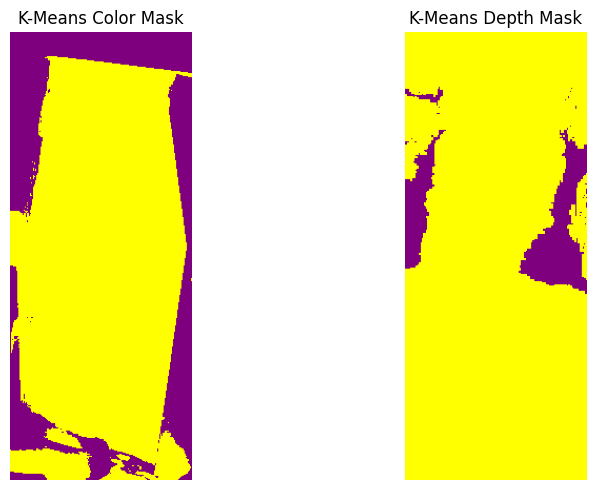

Displayed K-Means foreground masks for color and depth ROIs in a row with custom colors.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors # Import matplotlib.colors

# Define custom colormap for binary masks: False (0) for violet, True (1) for yellow
colors = [(0.5, 0.0, 0.5), (1.0, 1.0, 0.0)] # Violet and Yellow (RGB)
custom_cmap = matplotlib.colors.ListedColormap(colors)

# Display the K-Means masks in a single row
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(kmeans_color_mask_cropped, cmap=custom_cmap) # Use custom_cmap
plt.title('K-Means Color Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(kmeans_depth_mask_cropped, cmap=custom_cmap) # Use custom_cmap
plt.title('K-Means Depth Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Displayed K-Means foreground masks for color and depth ROIs in a row with custom colors.")

# Task 1.3 Convert the clustering results into a segmentation image.

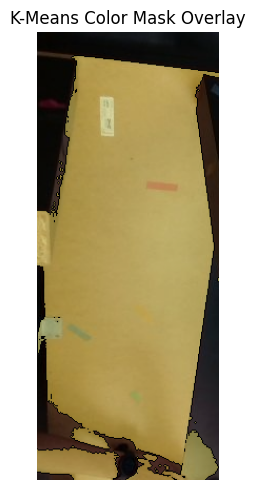

In [11]:
# First we need a overlay function to overlay the mask
from scipy.ndimage import binary_dilation
import numpy as np # Ensure numpy is imported

def overlay_function(image, mask, alpha=0.3):
    '''
    image: input rgb image
    mask:  a boolean mask (True for foreground, False for background)
    '''

    # Define colors for False (0) -> Violet, True (1) -> Yellow
    # These are RGB values for the background and foreground of the mask visualization.
    color_map = [
        [0, 0, 0],
        [255, 255, 50],
        [255, 50, 50],
        [50, 255, 50],
        [50, 50, 255],
        [255, 50, 255],
        [50, 255, 255]

    ]

    color_map_np = np.array(color_map, dtype=np.uint8) # Ensure dtype is uint8

    im_overlay = image.copy()

    # Convert the boolean mask to integer (0 or 1) so it can be used as an index
    indexed_mask = mask.astype(np.uint8) # False becomes 0, True becomes 1
    colored_mask = color_map_np[indexed_mask]
    # Blend foreground (yellow) region of the mask with the original image
    im_overlay[mask] = (image[mask].astype(np.float32) * (1 - alpha) + colored_mask[mask].astype(np.float32) * alpha).astype(np.uint8)

    # Blend background (violet) region of the mask with the original image
    im_overlay[~mask] = (image[~mask].astype(np.float32) * (1 - alpha) + colored_mask[~mask].astype(np.float32) * alpha).astype(np.uint8)

    contours = binary_dilation(mask) ^ mask
    im_overlay[contours, :] = 0

    return im_overlay.astype(image.dtype)

# Display the K-Means masks in a single row
plt.figure(figsize=(10, 5))

plt.subplot(1, 1, 1)
segmentation_image = overlay_function(cropped_color_roi, kmeans_color_mask_cropped)

plt.imshow(segmentation_image)
plt.title('K-Means Color Mask Overlay')
plt.axis('off')


plt.tight_layout()
plt.show()

## Task 2 Mask R-CNN (2 Students):
### 2.1 Fine-tune Mask R-CNN using Detectron2.
-  for this task we use the same fineuned yolov8 which can deliver semantic segmentation

Visualizing 1 random validation images...


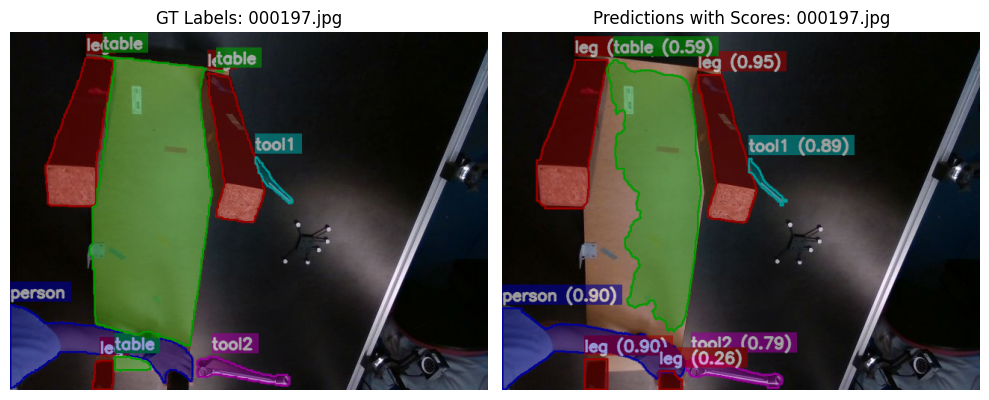

In [12]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np # Added numpy import

# Define a new helper function to draw masks with scores
def draw_masks_and_scores(image, masks_with_scores, classes):
    """
    Draws segmentation masks, class labels, and confidence scores on an image with semi-transparent colors.
    """
    img_copy = image.copy()
    overlay = img_copy.copy()
    alpha = 0.4  # Transparency factor

    # Define a set of distinct colors for classes (BGR format for OpenCV)
    class_colors = [
        (0, 0, 155),    # Red for class 0 (person)
        (0, 155, 0),    # Green for class 1 (table)
        (155, 0, 0),    # Blue for class 2 (leg)
        (0, 155, 155),  # Yellow for class 3 (tool1)
        (155, 0, 155)   # Magenta for class 4 (tool2)
    ]

    for class_id, polygon_points, score in masks_with_scores:
        if polygon_points:
            # Get color for the class
            color = class_colors[class_id % len(class_colors)] if class_id < len(class_colors) else (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) # Fallback random color

            # Reshape points for cv2.fillPoly and cv2.polylines
            pts = np.array(polygon_points, np.int32)
            pts = pts.reshape((-1, 1, 2))

            # Fill the polygon on the overlay with semi-transparency
            cv2.fillPoly(overlay, [pts], color)

            # Draw polygon outline
            cv2.polylines(img_copy, [pts], True, color, 2)

            # Put label with score
            label_text = classes[class_id] if class_id < len(classes) else f"Unknown Class {class_id}"
            label_text = f"{label_text} ({score:.2f})" # Add score here

            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.7
            font_thickness = 2
            text_size = cv2.getTextSize(label_text, font, font_scale, font_thickness)[0]

            # Place text near the first point of the polygon
            text_x = polygon_points[0][0]
            text_y = polygon_points[0][1] - 10 if polygon_points[0][1] - 10 > text_size[1] else polygon_points[0][1] + text_size[1] + 10

            # Draw background for text
            cv2.rectangle(img_copy, (text_x, text_y - text_size[1] - 5),
                          (text_x + text_size[0] + 5, text_y + 5), color, -1)
            cv2.putText(img_copy, label_text, (text_x, text_y), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)

    # Combine the original image with the overlay using the transparency factor
    img_with_masks = cv2.addWeighted(overlay, alpha, img_copy, 1 - alpha, 0)
    return img_with_masks


print(f"Visualizing {num_images_to_visualize} random validation images...")

plt.figure(figsize=(10, 5))

for i, img_filename in enumerate(selected_images_for_viz):
    img_path = os.path.join(val_images_dir, img_filename)
    label_filename = os.path.splitext(img_filename)[0] + '.txt'
    label_path = os.path.join(val_labels_dir, label_filename)

    # Read the image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image: {img_path}")
        continue

    # OpenCV reads images as BGR, convert to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get image dimensions for parsing labels
    img_height, img_width, _ = img_rgb.shape

    # --- Ground Truth Labels ---
    gt_masks = parse_yolo_label(label_path, img_width, img_height)
    img_with_gt = draw_bboxes_and_labels(img_rgb.copy(), gt_masks, CLASSES)

    # --- Model Predictions ---
    # Run inference
    results = model(img_rgb, verbose=False) # verbose=False to suppress output for each image

    # Process results to get masks in the desired format
    predicted_masks_with_scores = []
    for r in results:
        if r.masks is not None:
            for j, mask_data in enumerate(r.masks.data):
                class_id = int(r.boxes.cls[j])
                confidence_score = float(r.boxes.conf[j]) # Get confidence score
                # Convert mask to polygon points
                mask_np = mask_data.cpu().numpy().astype(np.uint8)
                contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    # Take the largest contour for simplicity if multiple are found
                    contour = max(contours, key=cv2.contourArea)
                    # Reshape to (N, 2) list of tuples for draw_masks_and_scores
                    polygon_points = [tuple(point[0]) for point in contour]
                    predicted_masks_with_scores.append((class_id, polygon_points, confidence_score)) # Append score

    # Draw bounding boxes and labels using the newly defined helper function
    img_with_predictions = draw_masks_and_scores(img_rgb.copy(), predicted_masks_with_scores, CLASSES)

    # --- Display Both ---
    plt.subplot(num_images_to_visualize, 2, i * 2 + 1) # First column for GT
    plt.imshow(img_with_gt)
    plt.title(f"GT Labels: {img_filename}")
    plt.axis('off')

    plt.subplot(num_images_to_visualize, 2, i * 2 + 2) # Second column for Predictions
    plt.imshow(img_with_predictions)
    plt.title(f"Predictions with Scores: {img_filename}")
    plt.axis('off')

plt.tight_layout()
plt.show()



# Task 2.3: Depth Smoothing


--- Task 2.3: Depth Smoothing ---


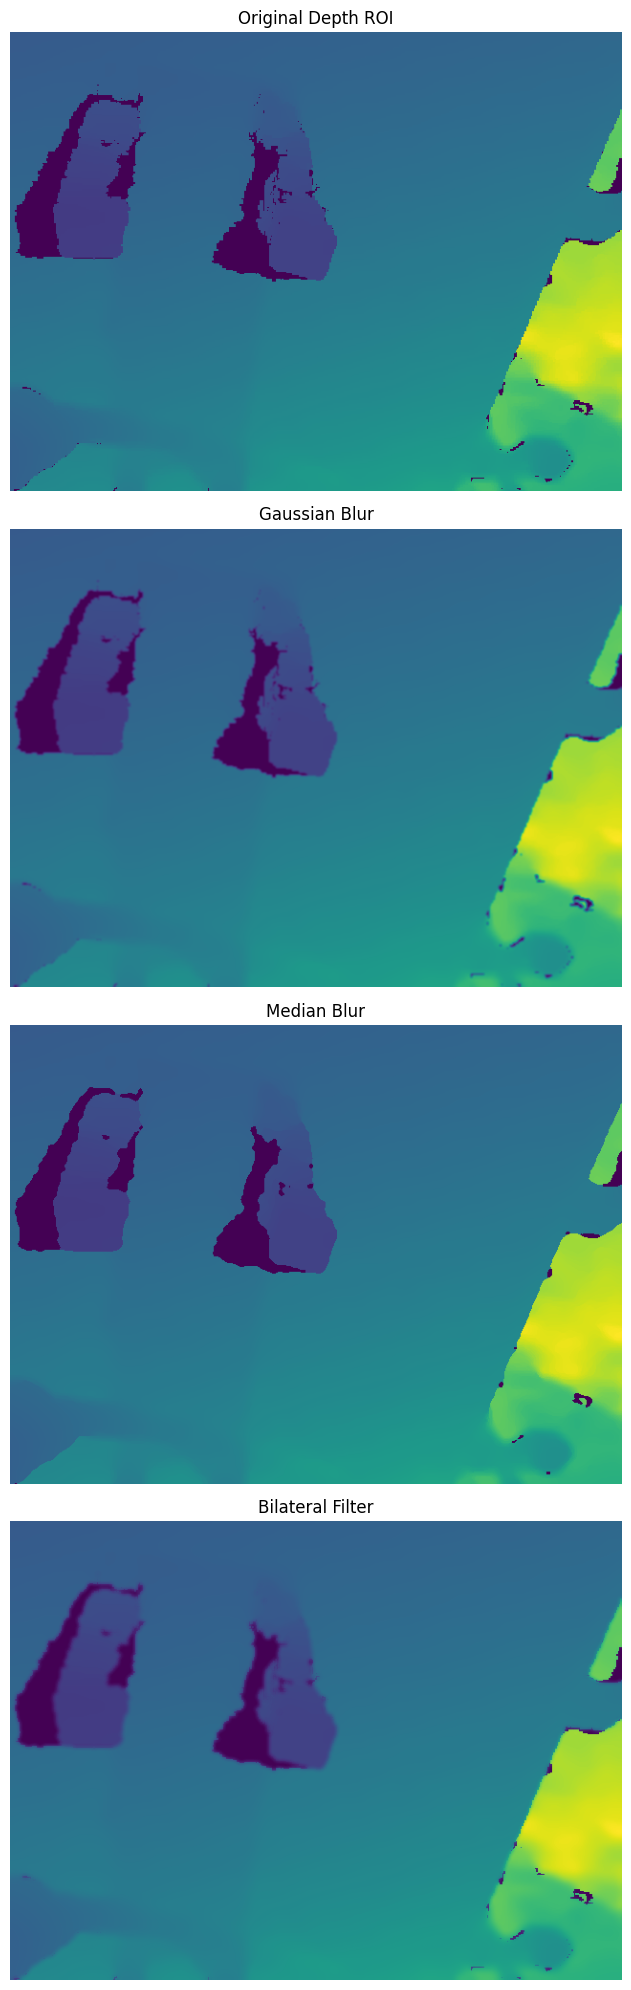

In [32]:
print("\n--- Task 2.3: Depth Smoothing ---")

# Apply opencv blurring filters
depth_gaussian  = cv2.GaussianBlur(normalized_depth_image, (5,5), 0)
depth_median    = cv2.medianBlur(normalized_depth_image, 5)
depth_bilateral = cv2.bilateralFilter(normalized_depth_image, 9, 75, 75)

# Plot
plt.figure(figsize=(30,20))

plt.subplot(4,1,1)
plt.imshow(normalized_depth_image, cmap='viridis')
plt.title("Original Depth ROI")
plt.axis('off')

plt.subplot(4,1,2)
plt.imshow(depth_gaussian, cmap='viridis')
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(4,1,3)
plt.imshow(depth_median, cmap='viridis')
plt.title("Median Blur")
plt.axis('off')

plt.subplot(4,1,4)
plt.imshow(depth_bilateral, cmap='viridis')
plt.title("Bilateral Filter")
plt.axis('off')

plt.tight_layout()
plt.show()